# FASE 2: Desarrollo y Entrenamiento de modelos

In [1]:
import tf2onnx
import onnx
import keras_tuner as kt
import onnxruntime as ort
import xgboost as xgb
import onnxmltools
from onnxmltools.convert.common.data_types import FloatTensorType
import skl2onnx
from skl2onnx import to_onnx
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

In [2]:
import datetime
import seaborn as sns
import holidays
import pandas as pd
import numpy as np
import joblib
from keras.optimizers import Adam
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pandas import read_csv
import tensorflow as tf
from keras.models import Model
from keras.layers import LSTM, Dense, Dropout, Input
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.interpolate import make_interp_spline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML

In [5]:
df_completo=read_csv('../data/ventasT.csv')
df_completo['Fecha_Venta'] = pd.to_datetime(df_completo['Fecha_Venta'], format='%Y-%m-%d', errors='coerce')

## Ingeniería de Características

Vamos a crear nuevas variables, las cuales permitirán que el modelo identifique diferentes comportamientos en las ventas según los días del mes

In [6]:
#Extraemos el número del mes
df_completo['Mes']=df_completo['Fecha_Venta'].dt.month
#Agregamos la variable
df_completo['Día_Mes']=df_completo['Fecha_Venta'].dt.day
#Extraemos el día de la semana
df_completo['Dia_Semana']=df_completo['Fecha_Venta'].dt.dayofweek
#Creamos bandera de fin de semana
df_completo['Es_FinSemana']=(df_completo['Dia_Semana']>=5).astype(int)

#Cargamos el calendario para verificar feriados
calendario_feriados = holidays.country_holidays('EC', years=2024)
#Verificamos cada día presente en el calendario para comprobar si es feriado o no
df_completo['Es_feriado']=df_completo['Fecha_Venta'].apply(lambda x: x in calendario_feriados).astype(int)
#Crear columna de vispera de feriado, que indica si el siguiente dia será feriado
df_completo['Vispera_Feriado']=df_completo['Fecha_Venta'].apply(lambda x: int((x + pd.Timedelta(days=1)) in calendario_feriados))

In [7]:
df_completo.to_csv('../data/ventasT.csv', index=False)
df_completo.head()

,Fecha_Venta,ID_Producto,Cantidad,Cantidad_1_dias,Cantidad_2_dias,Cantidad_3_dias,Cantidad_4_dias,Cantidad_5_dias,Cantidad_6_dias,Cantidad_7_dias,Mes,Día_Mes,Dia_Semana,Es_FinSemana,Es_feriado,Vispera_Feriado
0,2024-02-07,1,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,2,7,2,0,0,0
1,2024-02-08,1,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,2,8,3,0,0,0
2,2024-02-09,1,6.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,2,9,4,0,0,0
3,2024-02-10,1,0.0,6.0,0.0,0.0,3.0,0.0,0.0,0.0,2,10,5,1,0,0
4,2024-02-11,1,0.0,0.0,6.0,0.0,0.0,3.0,0.0,0.0,2,11,6,1,0,1


## Preparación de conjuntos train-set

In [8]:
df_completo=pd.read_csv('../data/ventasT.csv')
df_completo['Fecha_Venta'] = pd.to_datetime(df_completo['Fecha_Venta'], format='%Y-%m-%d', errors='coerce')
#Separar la variable objetivo
X = df_completo.drop(columns=[ 'Fecha_Venta', 'Cantidad'])
y = df_completo['Cantidad']

#division train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

#Escalar los datos de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f" - Train: {X_train_scaled.shape[0]} registros.")
print(f" - Test: {X_test_scaled.shape[0]} registros.")

 - Train: 9971 registros.
 - Test: 2493 registros.


## RED NEURONAL CON API FUNCTIONAL

In [9]:
n_features = X_train_scaled.shape[1]
#Entrada
entrada = Input(shape=(n_features,), name='Capa_Entrada')
#Capas Ocultas
x = Dense(64, activation='relu', name='Oculta_1')(entrada)
x = Dropout(0.2, name='Prevencion_Sobreajuste')(x)
x = Dense(32, activation='relu', name='Oculta_2')(x)
#Salida
salida = Dense(1, activation='linear', name='Prediccion_Cantidad')(x)

modelo_nn = Model(inputs=entrada, outputs=salida, name='Modelo_Funcional_Ventas')
modelo_nn.compile(optimizer='adam', loss='mse', metrics=['mae'])
modelo_nn.summary()

Model: "Modelo_Funcional_Ventas"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Entrada (InputLayer)       │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Oculta_1 (Dense)                │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Prevencion_Sobreajuste          │ (None, 64)             │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Oculta_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Prediccion_Cantidad (Dense)     │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#Entrenamiento
historial_nn = modelo_nn.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)
#Test
predicciones_nn = modelo_nn.predict(X_test_scaled)
mae_nn = mean_absolute_error(y_test, predicciones_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, predicciones_nn))

print(f"\nMétricas:")
print(f" - MAE: {mae_nn:.2f} unidades")
print(f" - RMSE: {rmse_nn:.2f} unidades")

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

Métricas:
 - MAE: 1.42 unidades
 - RMSE: 1.88 unidades


In [11]:
#Exportación a ONNX
spec = (tf.TensorSpec((None, n_features), tf.float32, name="input"),)
output_path_nn = "../models/modelo_red_neuronal.onnx"
# Convertimos y guardamos
model_proto, _ = tf2onnx.convert.from_keras(modelo_nn, input_signature=spec, output_path=output_path_nn)

## XGBoost

In [12]:
modelo_xgb=xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)
#Entrenamiento
modelo_xgb.fit(X_train_scaled, y_train)
#Testing
predicciones_xgb=modelo_xgb.predict(X_test_scaled)
mae_xgb = mean_absolute_error(y_test, predicciones_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, predicciones_xgb))

print(f"\nMétricas:")
print(f" - MAE: {mae_xgb:.2f} unidades")
print(f" - RMSE: {rmse_xgb:.2f} unidades")


Métricas:
 - MAE: 1.18 unidades
 - RMSE: 1.86 unidades


In [13]:
#EXportar a ONNX
n_features=X_train_scaled.shape[1]
initial_type=[('float_input',FloatTensorType([None, n_features]))]
onnx_model_xgb = onnxmltools.convert_xgboost(modelo_xgb, initial_types=initial_type)
#Guardar en google drive
output_path_xgb="../models/modelo_xgboost.onnx"
with open(output_path_xgb, "wb") as f:
  f.write(onnx_model_xgb.SerializeToString())

## Bagging

In [14]:
#MOdelo base de arbol de decision
modelo_base =DecisionTreeRegressor(max_depth=6, random_state=42)
#Ensabmle con 50 arboles
modelo_bagging=BaggingRegressor(
    estimator=modelo_base,
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
#Train
modelo_bagging.fit(X_train_scaled, y_train)
#TEsting
predicciones_bagging=modelo_bagging.predict(X_test_scaled)
mae_bagging=mean_absolute_error(y_test, predicciones_bagging)
rmse_bagging=np.sqrt(mean_squared_error(y_test, predicciones_bagging))

print(f"\nMétricas:")
print(f" - MAE: {mae_bagging:.2f} unidades")
print(f" - RMSE: {rmse_bagging:.2f} unidades")


Métricas:
 - MAE: 1.20 unidades
 - RMSE: 1.79 unidades


In [15]:
#Exportar a ONNX
onnx_model_bagging = to_onnx(modelo_bagging, X_train_scaled[:1].astype(np.float32))

#Guardar en drive
output_path_bagging="../models/modelo_bagging.onnx"
with open(output_path_bagging, "wb") as f:
  f.write(onnx_model_bagging.SerializeToString())

## Comparación de modelos

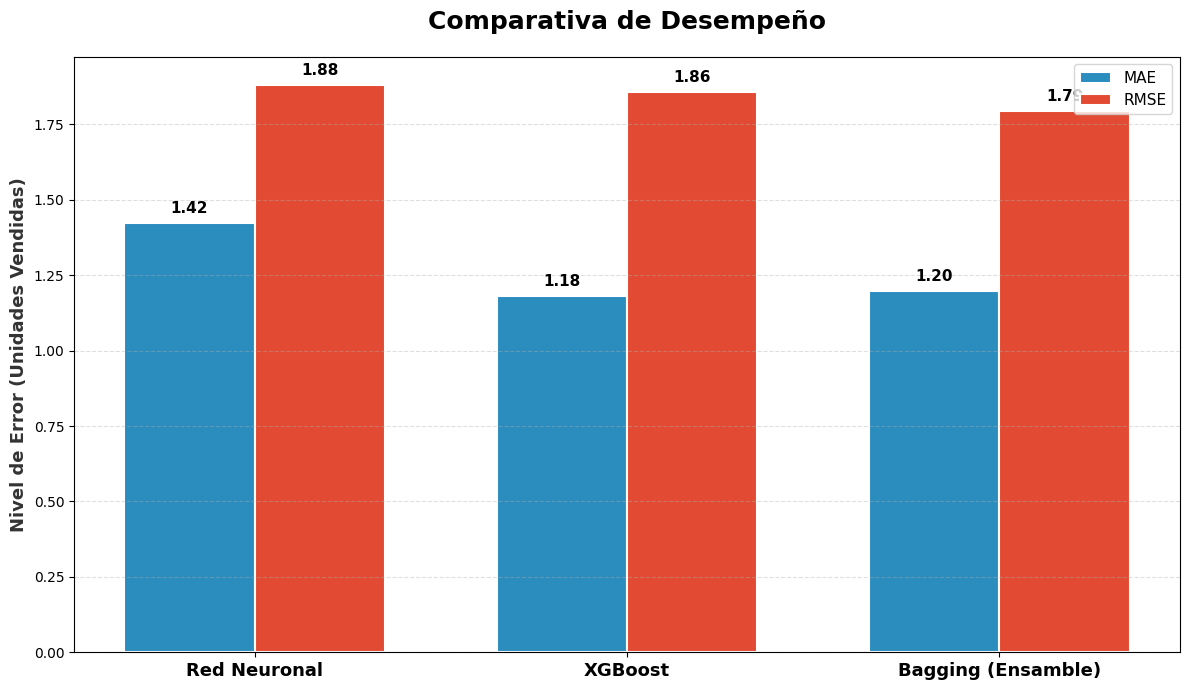


Mejor modelo según el MAE: XGBOOST


In [16]:
#Recopilar los resultados
resultados = {
    'Modelo': ['Red Neuronal', 'XGBoost', 'Bagging (Ensamble)'],
    'MAE': [mae_nn, mae_xgb, mae_bagging],
    'RMSE': [rmse_nn, rmse_xgb, rmse_bagging]
}
df_resultados = pd.DataFrame(resultados)

# Graficar
x = np.arange(len(df_resultados['Modelo']))
ancho = 0.35
fig, ax = plt.subplots(figsize=(12, 7))
barras_mae = ax.bar(x - ancho/2, df_resultados['MAE'], ancho,
                    label='MAE', color='#2b8cbe', edgecolor='white', linewidth=1.5)
barras_rmse = ax.bar(x + ancho/2, df_resultados['RMSE'], ancho,
                     label='RMSE', color='#e34a33', edgecolor='white', linewidth=1.5)
ax.set_ylabel('Nivel de Error (Unidades Vendidas)', fontsize=13, fontweight='bold', color='#333333')
ax.set_title('Comparativa de Desempeño', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_resultados['Modelo'], fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')

#Poner el numero encima de cada barra
def agregar_etiquetas(barras):
    for barra in barras:
        alto = barra.get_height()
        ax.annotate(f'{alto:.2f}',
                    xy=(barra.get_x() + barra.get_width() / 2, alto),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

agregar_etiquetas(barras_mae)
agregar_etiquetas(barras_rmse)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Imprimir conclusión
mejor_modelo = df_resultados.loc[df_resultados['MAE'].idxmin(), 'Modelo']
print(f"\nMejor modelo según el MAE: {mejor_modelo.upper()}")

## Creación de funciones

In [18]:
#Cargar requisitos, aparte se deben cargar imports y montar drive
#MOdelo
ruta_modelo_onnx = "../models/modelo_xgboost.onnx"
session_xgb = ort.InferenceSession(ruta_modelo_onnx)
nombre_entrada = session_xgb.get_inputs()[0].name
#Dataframes
df_productos=pd.read_csv('../data/productos.csv')
df_completo=pd.read_csv('../data/ventasT.csv')
df_completo['Fecha_Venta'] = pd.to_datetime(df_completo['Fecha_Venta'], format='%Y-%m-%d', errors='coerce')
#Calendario
calendario_feriados=holidays.country_holidays('EC', years=2024)

### Predicción individual

In [19]:
def predecir_venta(id_producto, fecha):
    """
    Predice las ventas de un producto específico para una fecha determinada.
    """
    #Convertir la fecha a formato datetime
    fecha_dt = pd.to_datetime(fecha)

    #Filtrar la historia de este producto
    historia_producto = df_completo[(df_completo['ID_Producto'] == id_producto) &
                                     (df_completo['Fecha_Venta'] < fecha_dt)].sort_values('Fecha_Venta', ascending=False)

    #Extraer los últimos 7 días de ventas
    # Si es un producto muy nuevo y no tiene 7 días, rellenamos con 0
    ventas_pasadas = historia_producto['Cantidad'].head(7).tolist()
    while len(ventas_pasadas) < 7:
        ventas_pasadas.append(0.0)

    #Calcular variables de calendario
    mes = fecha_dt.month
    dia_mes = fecha_dt.day
    dia_semana = fecha_dt.dayofweek
    es_finde = 1 if dia_semana >= 5 else 0

    # Para feriados y vísperas, asumiremos 0 en proyecciones futuras a menos que se cruce con un calendario de festivos
    es_feriado = 1 if fecha_dt in calendario_feriados else 0
    dia_siguiente= fecha_dt + pd.Timedelta(days=1)
    vispera_feriado =1 if dia_siguiente in calendario_feriados else 0

    #Construir la fila exacta de 14 columnas que se usó en train
    nombres_columnas = [
        'ID_Producto', 'Cantidad_1_dias', 'Cantidad_2_dias', 'Cantidad_3_dias',
        'Cantidad_4_dias', 'Cantidad_5_dias', 'Cantidad_6_dias', 'Cantidad_7_dias',
        'Mes', 'Día_Mes', 'Dia_Semana', 'Es_FinSemana', 'Es_feriado', 'Vispera_Feriado'
    ]
    caracteristicas = pd.DataFrame([[
        id_producto,
        ventas_pasadas[0], ventas_pasadas[1], ventas_pasadas[2], ventas_pasadas[3],
        ventas_pasadas[4], ventas_pasadas[5], ventas_pasadas[6],
        mes, dia_mes, dia_semana, es_finde, es_feriado, vispera_feriado
    ]], columns=nombres_columnas)

    #Escalar los datos usando el mismo escalador del entrenamiento
    caracteristicas_escaladas = scaler.transform(caracteristicas)

    # Ejecutar la predicción usando ONNX Runtime
    inputs_onnx = {nombre_entrada: caracteristicas_escaladas.astype(np.float32)}
    prediccion_onnx = session_xgb.run(None, inputs_onnx)[0]
    prediccion_cruda = prediccion_onnx.flatten()[0]

    prediccion_final = max(0, int(round(prediccion_cruda)))

    return prediccion_final

### Predicción en batches

In [20]:
def predecir_lote(lista_ids, fecha):
    """
    Recibe una lista de IDs y una fecha, y devuelve un DataFrame con las predicciones.
    """
    resultados = []
    for id_prod in lista_ids:
        # Reutilizamos la funcion individual
        pred_unidades = predecir_venta(id_prod, fecha)

        #Buscar el nombre del producto
        try:
            nombre = df_productos[df_productos['ID_Producto'] == id_prod]['Nombre_producto'].iloc[0]
        except:
            nombre = "Desconocido"

        resultados.append({
            'Fecha_Objetivo': fecha,
            'ID_Producto': id_prod,
            'Nombre_Producto': nombre,
            'Unidades_Proyectadas': pred_unidades
        })

    #Empaquetar todo en un DataFrame
    df_predicciones = pd.DataFrame(resultados)
    return df_predicciones

### Test de Funciones

- Catalogo

In [21]:
print("Catálogo de Productos:")
tabla_html = df_productos[['ID_Producto', 'Nombre_producto']].to_html(index=False, justify='left', classes='table table-striped')
caja_pequena = f"""
<div style="max-width: 350px; max-height: 200px; overflow-y: auto; border: 1px solid #e0e0e0; border-radius: 8px; padding: 5px; background-color: gray;">
    {tabla_html}
</div>
"""
display(HTML(caja_pequena))

Catálogo de Productos:


ID_Producto,Nombre_producto
1,Leche
2,Yogur
3,Queso cremoso
4,Queso rallado
5,Manteca
6,Asado
7,Chorizo
8,Milanesa
9,Pollo
10,Costilla de cerdo


---
- Prediccion individual

In [22]:
fecha="2024-06-03"
id_test=27

prediccion=predecir_venta(id_test,fecha)
print(f"Prediccion para el producto {id_test}: {prediccion}  unidades")

Prediccion para el producto 27: 2  unidades


---
- Prediccion en batches

In [23]:
productos=[32,31,27,25,23,12,29,38,29]
fecha="2024-12-25"

prediccion=predecir_lote(productos,fecha)
display(prediccion)

,Fecha_Objetivo,ID_Producto,Nombre_Producto,Unidades_Proyectadas
0,2024-12-25,32,Galletitas de chocolate,2
1,2024-12-25,31,Galletitas de agua,2
2,2024-12-25,27,Agua mineral,1
3,2024-12-25,25,Pizza congelada,1
4,2024-12-25,23,Papas fritas,1
5,2024-12-25,12,Pan francés,2
6,2024-12-25,29,Cerveza,1
7,2024-12-25,38,Atún enlatado,1
8,2024-12-25,29,Cerveza,1
